In [124]:
import pandas as pd
import kagglehub

print("Pandas:", pd.__version__)
print("KaggleHub:", kagglehub.__version__)

Pandas: 3.0.5
KaggleHub: 1.0.2


In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\amand\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [26]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [27]:
import pandas as pd

arquivo = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(arquivo)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 7043
Colunas: 21


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [30]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [31]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [32]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
df["TotalCharges"].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [34]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [35]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [36]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [37]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [38]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [39]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [40]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [41]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [43]:
df["customerID"].nunique()

7043

In [44]:
df["Churn"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [45]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [46]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [47]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [48]:
X = df.drop(columns=["Churn"])

In [49]:
y = df["Churn"]

In [50]:
X = df.drop(columns=["Churn"])

y = df["Churn"]

In [51]:
X.shape

(7043, 20)

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
import pandas as pd

In [54]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print(path)

C:\Users\amand\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [55]:
import os

arquivo = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(arquivo)

In [56]:
df.shape

(7043, 21)

In [57]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [58]:
X = df.drop("Churn", axis=1)

In [59]:
y = df["Churn"]

In [60]:
X.shape

(7043, 20)

In [61]:
y.shape

(7043,)

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 20)
(1409, 20)
(5634,)
(1409,)


In [65]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [66]:
df["TotalCharges"].dtype

dtype('float64')

In [67]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
print(X_train.shape)
print(X_test.shape)

(5634, 20)
(1409, 20)


In [70]:
X.select_dtypes(include="object").columns

C:\Users\amand\AppData\Local\Temp\ipykernel_21264\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [71]:
X = pd.get_dummies(X, drop_first=True)

X.shape

(7043, 7072)

In [72]:
X.dtypes.value_counts()

bool       7068
int64         2
float64       2
Name: count, dtype: int64

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
model = LogisticRegression(max_iter=1000)

In [75]:
X.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF', 'customerID_0013-SMEOE',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str', length=7072)

In [76]:
X = df.drop(columns=["Churn", "customerID"])

In [77]:
X = pd.get_dummies(X, drop_first=True)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

In [80]:
X_train.isna().sum().sort_values(ascending=False)

TotalCharges                             8
SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

In [81]:
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

In [82]:
X["TotalCharges"] = X["TotalCharges"].fillna(0)

In [83]:
X.isna().sum().sum()

np.int64(0)

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
X_train.isna().sum().sum()

np.int64(0)

In [86]:
X_train.isna().sum().sum()

np.int64(0)

In [87]:
X_test.isna().sum().sum()

np.int64(0)

In [88]:
model.fit(X_train, y_train)

c:\Users\amand\OneDrive\Documentos\AI-Data-Analyst\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [89]:
X_test

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,False,True,False,True,False,True,True,True,False,False
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,False,True,False,True,False,False,True,True,False,False
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,True,False,False,True,False,True,True,False,False
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,False,True,False,True,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0,49,87.20,4345.00,False,True,True,True,False,False,...,False,True,False,True,True,False,True,False,False,True
4439,0,28,20.30,487.95,True,True,True,True,False,False,...,True,False,True,False,False,True,True,True,False,False
3857,0,5,20.65,93.55,True,False,False,True,False,False,...,True,False,True,False,False,False,False,False,False,False
4758,0,56,19.70,1051.90,False,False,False,True,False,False,...,True,False,True,False,False,True,False,False,False,False


In [90]:
y_pred = model.predict(X_test)

In [91]:
y_pred

array(['No', 'Yes', 'No', ..., 'No', 'No', 'No'],
      shape=(1409,), dtype=object)

In [92]:
from sklearn.metrics import accuracy_score

In [93]:
accuracy_score

<function sklearn.metrics._classification.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)>

In [94]:
accuracy = accuracy_score(y_test, y_pred)

In [95]:
accuracy

0.8041163946061036

In [96]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [166 208]]


In [97]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [98]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [100]:
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [101]:
y_pred_rf = model_rf.predict(X_test)

In [102]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [103]:
y_prob = model.predict_proba(X_test)[:, 1]

In [104]:
threshold = 0.40

y_pred_threshold = (y_prob >= threshold).astype(int)

In [105]:
import numpy as np

In [106]:
y_pred_threshold = np.where(y_prob >= threshold, "Yes", "No")

In [107]:
print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

          No       0.87      0.82      0.84      1035
         Yes       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [108]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = np.where(y_prob >= threshold, "Yes", "No")
    
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred_threshold, digits=2))


Threshold: 0.3
              precision    recall  f1-score   support

          No       0.90      0.75      0.82      1035
         Yes       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Threshold: 0.35
              precision    recall  f1-score   support

          No       0.88      0.79      0.83      1035
         Yes       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409


Threshold: 0.4
              precision    recall  f1-score   support

          No       0.87      0.82      0.84      1035
         Yes       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79  

In [109]:
for threshold in thresholds:
    y_pred_threshold = np.where(y_prob >= threshold, "Yes", "No")
    
    report = classification_report(
        y_test,
        y_pred_threshold,
        output_dict=True
    )
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Recall Yes: {report['Yes']['recall']:.2f} | "
        f"Precision Yes: {report['Yes']['precision']:.2f} | "
        f"F1 Yes: {report['Yes']['f1-score']:.2f} | "
        f"Accuracy: {report['accuracy']:.2f}"
    )

Threshold: 0.30 | Recall Yes: 0.76 | Precision Yes: 0.52 | F1 Yes: 0.62 | Accuracy: 0.75
Threshold: 0.35 | Recall Yes: 0.70 | Precision Yes: 0.54 | F1 Yes: 0.61 | Accuracy: 0.76
Threshold: 0.40 | Recall Yes: 0.67 | Precision Yes: 0.57 | F1 Yes: 0.62 | Accuracy: 0.78
Threshold: 0.45 | Recall Yes: 0.62 | Precision Yes: 0.60 | F1 Yes: 0.61 | Accuracy: 0.79
Threshold: 0.50 | Recall Yes: 0.56 | Precision Yes: 0.65 | F1 Yes: 0.60 | Accuracy: 0.80
Threshold: 0.55 | Recall Yes: 0.47 | Precision Yes: 0.69 | F1 Yes: 0.55 | Accuracy: 0.80
Threshold: 0.60 | Recall Yes: 0.40 | Precision Yes: 0.72 | F1 Yes: 0.51 | Accuracy: 0.80


In [110]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": model.coef_[0]
})

coeficientes["Impacto_Absoluto"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(
    "Impacto_Absoluto",
    ascending=False
)

coeficientes.head(15)

,Variavel,Coeficiente,Impacto_Absoluto
25,Contract_Two year,-1.328605,1.328605
10,InternetService_Fiber optic,0.744096,0.744096
24,Contract_One year,-0.685712,0.685712
7,PhoneService_Yes,-0.440448,0.440448
13,OnlineSecurity_Yes,-0.431675,0.431675
28,PaymentMethod_Electronic check,0.390784,0.390784
19,TechSupport_Yes,-0.384448,0.384448
26,PaperlessBilling_Yes,0.373610,0.373610
9,MultipleLines_Yes,0.274699,0.274699
6,Dependents_Yes,-0.221900,0.221900


In [111]:
coeficientes = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": model.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

coeficientes

,Variavel,Coeficiente
10,InternetService_Fiber optic,0.744096
28,PaymentMethod_Electronic check,0.390784
26,PaperlessBilling_Yes,0.373610
9,MultipleLines_Yes,0.274699
21,StreamingTV_Yes,0.198898
23,StreamingMovies_Yes,0.198237
8,MultipleLines_No phone service,0.166147
0,SeniorCitizen,0.145367
29,PaymentMethod_Mailed check,0.075469
5,Partner_Yes,0.023329


In [112]:
coeficientes.head(10)

,Variavel,Coeficiente
10,InternetService_Fiber optic,0.744096
28,PaymentMethod_Electronic check,0.390784
26,PaperlessBilling_Yes,0.373610
9,MultipleLines_Yes,0.274699
21,StreamingTV_Yes,0.198898
23,StreamingMovies_Yes,0.198237
8,MultipleLines_No phone service,0.166147
0,SeniorCitizen,0.145367
29,PaymentMethod_Mailed check,0.075469
5,Partner_Yes,0.023329


In [113]:
coeficientes.tail(10)

,Variavel,Coeficiente
18,TechSupport_No internet service,-0.109966
16,DeviceProtection_No internet service,-0.109966
20,StreamingTV_No internet service,-0.109966
15,OnlineBackup_Yes,-0.182348
6,Dependents_Yes,-0.221900
19,TechSupport_Yes,-0.384448
13,OnlineSecurity_Yes,-0.431675
7,PhoneService_Yes,-0.440448
24,Contract_One year,-0.685712
25,Contract_Two year,-1.328605


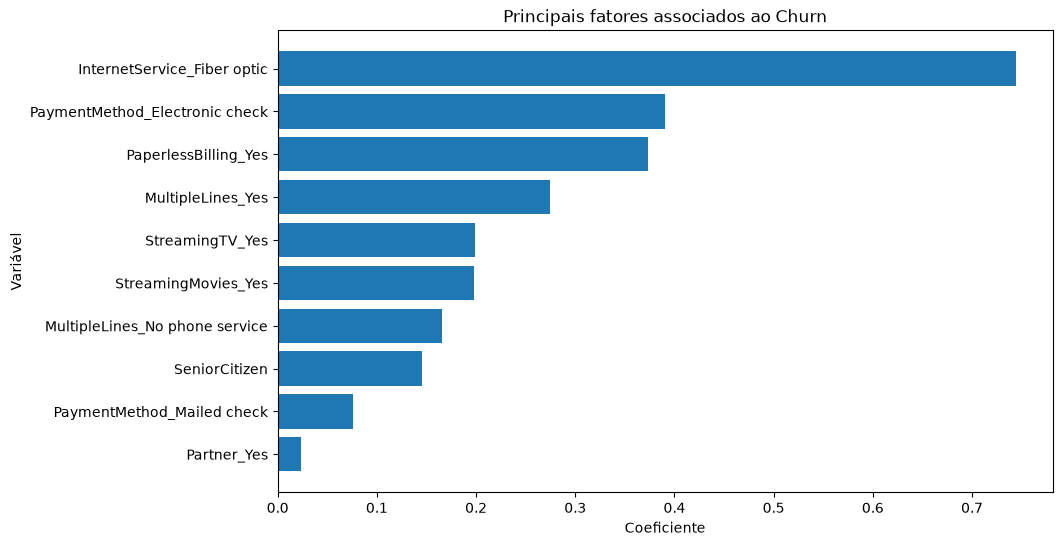

In [114]:
import matplotlib.pyplot as plt

top_10 = coeficientes.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Variavel"],
    top_10["Coeficiente"]
)

plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.title("Principais fatores associados ao Churn")

plt.gca().invert_yaxis()

plt.show()

In [115]:
probabilidades = model.predict_proba(X_test)[:, 1]

probabilidades[:10]

array([0.0466683 , 0.6818411 , 0.0632964 , 0.39189125, 0.02047635,
       0.59961026, 0.44163598, 0.12588432, 0.00268424, 0.39428747])

In [116]:
resultado = X_test.copy()

resultado["Probabilidade_Churn"] = probabilidades

resultado["Churn_Previsto"] = np.where(
    probabilidades >= 0.5,
    "Yes",
    "No"
)

resultado[["Probabilidade_Churn", "Churn_Previsto"]].head(10)

,Probabilidade_Churn,Churn_Previsto
437,0.046668,No
2280,0.681841,Yes
2235,0.063296,No
4460,0.391891,No
3761,0.020476,No
5748,0.599610,Yes
3568,0.441636,No
2976,0.125884,No
5928,0.002684,No
1639,0.394287,No


In [117]:
resultado["Churn_Previsto"] = np.where(
    resultado["Probabilidade_Churn"] >= 0.5,
    "Yes",
    "No"
)

resultado["Nivel_Risco"] = np.where(
    resultado["Probabilidade_Churn"] >= 0.5,
    "Alto",
    np.where(
        resultado["Probabilidade_Churn"] >= 0.3,
        "Médio",
        "Baixo"
    )
)

resultado[
    ["Probabilidade_Churn", "Churn_Previsto", "Nivel_Risco"]
].head(10)

,Probabilidade_Churn,Churn_Previsto,Nivel_Risco
437,0.046668,No,Baixo
2280,0.681841,Yes,Alto
2235,0.063296,No,Baixo
4460,0.391891,No,Médio
3761,0.020476,No,Baixo
5748,0.599610,Yes,Alto
3568,0.441636,No,Médio
2976,0.125884,No,Baixo
5928,0.002684,No,Baixo
1639,0.394287,No,Médio


In [118]:
resultado["Nivel_Risco"].value_counts()

Nivel_Risco
Baixo    869
Alto     318
Médio    222
Name: count, dtype: int64

In [119]:
resultado["Nivel_Risco"].value_counts(normalize=True) * 100

Nivel_Risco
Baixo    61.674947
Alto     22.569198
Médio    15.755855
Name: proportion, dtype: float64

In [120]:
    resultado["Nivel_Risco"].value_counts()

Nivel_Risco
Baixo    869
Alto     318
Médio    222
Name: count, dtype: int64

In [121]:
clientes_alto_risco = resultado[
    resultado["Nivel_Risco"] == "Alto"
]

clientes_alto_risco.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Probabilidade_Churn,Churn_Previsto,Nivel_Risco
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0.681841,Yes,Alto
5748,0,21,99.85,1992.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0.599610,Yes,Alto
3524,1,11,84.80,906.85,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0.681942,Yes,Alto
2136,0,15,91.00,1430.05,True,False,True,True,False,True,...,False,False,False,True,False,True,False,0.642960,Yes,Alto
6529,1,2,74.85,156.40,True,False,False,True,False,True,...,False,False,False,True,False,False,True,0.723725,Yes,Alto
761,0,22,89.25,1907.85,False,False,False,True,False,False,...,True,False,False,False,False,True,False,0.566481,Yes,Alto
6125,0,13,102.25,1359.00,True,True,False,True,False,True,...,True,False,False,True,True,False,False,0.699816,Yes,Alto
5547,0,3,89.45,240.45,False,False,False,True,False,False,...,True,False,False,True,False,True,False,0.773238,Yes,Alto
346,0,2,90.40,168.20,False,False,False,True,False,False,...,True,False,False,True,False,True,False,0.779542,Yes,Alto
6633,0,1,74.50,74.50,False,False,False,True,False,True,...,False,False,False,True,False,True,False,0.758129,Yes,Alto


In [122]:
clientes_alto_risco = resultado[
    resultado["Nivel_Risco"] == "Alto"
].copy()

clientes_alto_risco["customerID"] = df.loc[
    clientes_alto_risco.index,
    "customerID"
]

clientes_alto_risco[
    ["customerID", "Probabilidade_Churn", "Nivel_Risco", "Churn_Previsto"]
].head(10)

,customerID,Probabilidade_Churn,Nivel_Risco,Churn_Previsto
2280,2754-SDJRD,0.681841,Alto,Yes
5748,4686-UXDML,0.599610,Alto,Yes
3524,4706-AXVKM,0.681942,Alto,Yes
2136,1379-FRVEB,0.642960,Alto,Yes
6529,7235-NXZCP,0.723725,Alto,Yes
761,1894-IGFSG,0.566481,Alto,Yes
6125,0871-URUWO,0.699816,Alto,Yes
5547,9611-CTWIH,0.773238,Alto,Yes
346,2034-GDRCN,0.779542,Alto,Yes
6633,4415-IJZTP,0.758129,Alto,Yes


In [123]:
ranking_risco = clientes_alto_risco.sort_values(
    "Probabilidade_Churn",
    ascending=False
)

ranking_risco[
    ["customerID", "Probabilidade_Churn", "Nivel_Risco"]
].head(10)

,customerID,Probabilidade_Churn,Nivel_Risco
3380,5178-LMXOP,0.854599,Alto
6866,0295-PPHDO,0.832456,Alto
6365,8884-ADFVN,0.827070,Alto
2631,6861-XWTWQ,0.825130,Alto
3727,9057-SIHCH,0.821504,Alto
2797,6023-YEBUP,0.819479,Alto
6894,1400-MMYXY,0.818896,Alto
4585,1069-XAIEM,0.818600,Alto
3346,2545-EBUPK,0.814221,Alto
4039,8161-QYMTT,0.807805,Alto


In [125]:
ranking_risco[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract_One year",
        "Contract_Two year",
        "PaymentMethod_Electronic check",
        "InternetService_Fiber optic",
        "Probabilidade_Churn",
        "Nivel_Risco"
    ]
].head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Electronic check,InternetService_Fiber optic,Probabilidade_Churn,Nivel_Risco
3380,5178-LMXOP,1,95.10,95.10,False,False,True,True,0.854599,Alto
6866,0295-PPHDO,1,95.45,95.45,False,False,True,True,0.832456,Alto
6365,8884-ADFVN,7,101.95,700.85,False,False,True,True,0.827070,Alto
2631,6861-XWTWQ,7,99.25,665.45,False,False,True,True,0.825130,Alto
3727,9057-SIHCH,3,96.60,291.90,False,False,True,True,0.821504,Alto
2797,6023-YEBUP,3,100.95,329.95,False,False,True,True,0.819479,Alto
6894,1400-MMYXY,3,105.90,334.65,False,False,True,True,0.818896,Alto
4585,1069-XAIEM,1,85.05,85.05,False,False,True,True,0.818600,Alto
3346,2545-EBUPK,2,84.05,186.05,False,False,True,True,0.814221,Alto
4039,8161-QYMTT,7,94.10,701.30,False,False,True,True,0.807805,Alto


In [127]:
clientes_alto_risco[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

tenure             11.056604
MonthlyCharges     79.507075
TotalCharges      967.080818
dtype: float64

In [128]:
df[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

tenure              32.371149
MonthlyCharges      64.761692
TotalCharges      2283.300441
dtype: float64

In [129]:
clientes_alto_risco[
    [
        "Contract_One year",
        "Contract_Two year"
    ]
].mean()

Contract_One year    0.0
Contract_Two year    0.0
dtype: float64

In [130]:
df["Contract"].value_counts(normalize=True)

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64

In [131]:
clientes_alto_risco[
    "PaymentMethod_Electronic check"
].mean()

np.float64(0.7232704402515723)

In [132]:
df["PaymentMethod"].value_counts(normalize=True)

PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64

In [133]:
clientes_alto_risco[
    "InternetService_Fiber optic"
].mean()

np.float64(0.8867924528301887)

In [134]:
df["InternetService"].value_counts(normalize=True)

InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64

In [135]:
clientes_alto_risco["tenure"].describe()

count    318.000000
mean      11.056604
std       11.441386
min        1.000000
25%        2.000000
50%        7.000000
75%       17.000000
max       53.000000
Name: tenure, dtype: float64

In [136]:
clientes_alto_risco["Faixa_Tenure"] = pd.cut(
    clientes_alto_risco["tenure"],
    bins=[0, 6, 12, 24, float("inf")],
    labels=["0-6 meses", "7-12 meses", "13-24 meses", "25+ meses"]
)

clientes_alto_risco["Faixa_Tenure"].value_counts().sort_index()

Faixa_Tenure
0-6 meses      158
7-12 meses      53
13-24 meses     63
25+ meses       44
Name: count, dtype: int64

In [137]:
import matplotlib.pyplot as plt

print("Matplotlib funcionando!")

Matplotlib funcionando!


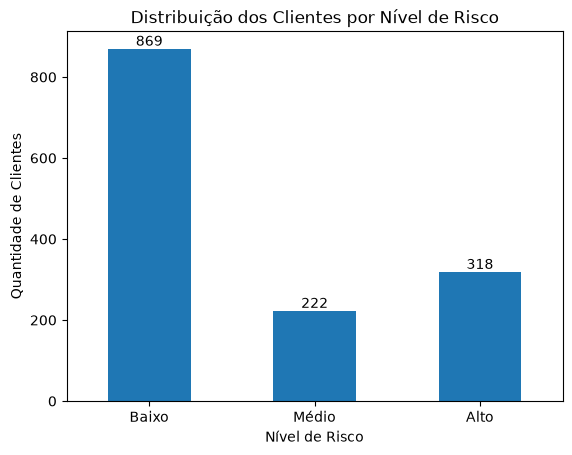

In [140]:
ordem_risco = ["Baixo", "Médio", "Alto"]

contagem_risco = (
    resultado["Nivel_Risco"]
    .value_counts()
    .reindex(ordem_risco)
)

ax = contagem_risco.plot(
    kind="bar",
    title="Distribuição dos Clientes por Nível de Risco",
    xlabel="Nível de Risco",
    ylabel="Quantidade de Clientes"
)

for barra in ax.patches:
    ax.annotate(
        int(barra.get_height()),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.show()

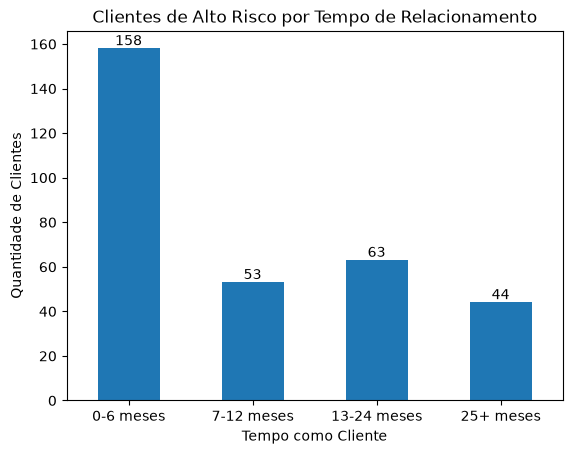

In [141]:
ordem_tenure = ["0-6 meses", "7-12 meses", "13-24 meses", "25+ meses"]

contagem_tenure = (
    clientes_alto_risco["Faixa_Tenure"]
    .value_counts()
    .reindex(ordem_tenure)
)

ax = contagem_tenure.plot(
    kind="bar",
    title="Clientes de Alto Risco por Tempo de Relacionamento",
    xlabel="Tempo como Cliente",
    ylabel="Quantidade de Clientes"
)

for barra in ax.patches:
    ax.annotate(
        int(barra.get_height()),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.show()

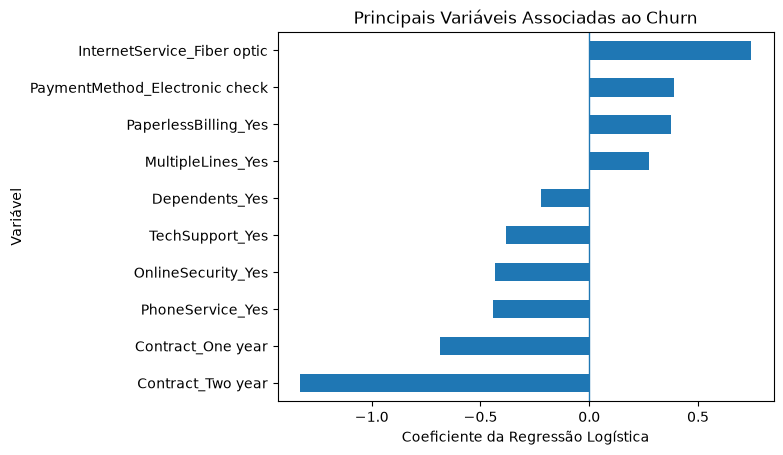

In [143]:
top_10_nomes = top_10.copy()

top_10_nomes.index = [
    X_train.columns[i]
    for i in top_10_nomes.index
]

ax = top_10_nomes.sort_values("Coeficiente")["Coeficiente"].plot(
    kind="barh",
    title="Principais Variáveis Associadas ao Churn",
    xlabel="Coeficiente da Regressão Logística",
    ylabel="Variável"
)

plt.axvline(0, linewidth=1)
plt.show()